In [1]:
import os
from pathlib import Path

project_root = "somedir/freqtrade"
i=0
try:
    os.chdirdir(project_root)
    assert Path('docker-compose.yml').is_file()
except:
    while i<4 and (not Path('docker-compose.yml').is_file()):
        os.chdir(Path(Path.cwd(), '../'))
        i+=1
    project_root = Path.cwd()
print(Path.cwd())

/root/defi


In [2]:
from freqtrade.configuration import Configuration

url = "user_data/cluster_strategy_v4_config.json"
config = Configuration.from_files([url])
config["strategy"] = "ClusterStrategyV4"
data_location = config["datadir"]
pair = 'WIF/USDT:USDT'

In [ ]:
!freqtrade download-data -c $url --pairs $pair -t 1m 3m

In [5]:
from freqtrade.data.history import load_pair_history
from freqtrade.enums import CandleType

dataframe_1m = load_pair_history(
    datadir=data_location,
    timeframe='1m',
    pair=pair,
    data_format = "feather",
    candle_type=CandleType.FUTURES,
)

In [61]:
dataframe_3m = load_pair_history(
    datadir=data_location,
    timeframe='3m',
    pair=pair,
    data_format = "feather",
    candle_type=CandleType.FUTURES,
)

In [1]:
import numpy as np

In [2]:
from freqtrade.strategy import stoploss_from_absolute

In [186]:
risk, current_rate = 0.005, 0.412
open_rate = 0.41
stop, reward = open_rate * (1 - risk), open_rate * (1 + 2 * risk)

In [228]:
borders = np.arange(0,1,0.1)
borders = np.sort(np.append(borders, (stop, open_rate, reward)))
border = borders[(borders < current_rate) & (borders >= stop)][-2]
stop = border if border > stop else stop
current_rate += 0.01
print(stop)
stoploss_from_absolute(stop, current_rate, False, 1)

0.5


0.0

In [370]:
risk, current_rate = 0.005, 0.409
open_rate = 0.41
stop, reward = open_rate / (1 - risk), open_rate / (1 + 2 * risk)

In [418]:
borders = np.arange(0,1,0.1)
borders = np.flip(np.sort(np.append(borders, (stop, open_rate, reward))))
border = borders[(borders > current_rate) & (borders <= stop)][-2]
stop = border if border < stop else stop
current_rate -= 0.01
print(f"borders: {borders}")
print(f"border: {border}")
print(f"stop: {stop}")
print(f"current_rate: {current_rate}")
stoploss_from_absolute(stop, current_rate, True, 1)

borders: [0.9        0.8        0.7        0.6        0.5        0.41
 0.40594059 0.4        0.3        0.2        0.1        0.1
 0.        ]
border: 0.1
stop: 0.1
current_rate: -0.06100000000000026


0.0

In [1]:
import numpy as np

In [2]:
borders = np.arange(0,10,1)
borders

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [12]:
from freqtrade_client import FtRestClient
server_url = 'http://127.0.0.1:8080'
username = ''
password = ""
client = FtRestClient(server_url, username, password)

In [39]:
client.status()[0]['profit_pct']

0.64

In [83]:
starting_balance = client.daily(1).get('data')[0].get('starting_balance')
dataframe = pd.DataFrame(client.trades().get('trades'))
dataframe['rel_stake'] = dataframe['stake_amount'] / starting_balance
dataframe['rel_profit'] = dataframe['close_profit_pct'] * dataframe['rel_stake']
rel_profit = dataframe[
    (dataframe.close_date > (date.today() - timedelta(days=1)).strftime('%Y-%m-%d')) &
    (dataframe.close_profit_pct > 0)
].rel_profit.sum()
rel_profit

8.591147258713216

In [6]:
stoploss = -0.02
max_stake = 300
min_stake = 5
risk = 0.3
max(min(max_stake * abs(stoploss) / risk, max_stake), min_stake)

20.0

In [1]:
import pandas as pd
from scipy.signal import argrelextrema
import numpy as np
import math

In [2]:
dataframe = pd.read_csv("out.csv")
# dataframe = dataframe[['date','open','high','low','close','volume']]
dataframe['date'] = pd.to_datetime(dataframe['date'])
dataframe[['date','&s-up_or_down']].tail(20)

,date,&s-up_or_down
979,2024-11-03 11:25:00+00:00,down
980,2024-11-03 11:30:00+00:00,down
981,2024-11-03 11:35:00+00:00,down
982,2024-11-03 11:40:00+00:00,down
983,2024-11-03 11:45:00+00:00,down
984,2024-11-03 11:50:00+00:00,up
985,2024-11-03 11:55:00+00:00,up
986,2024-11-03 12:00:00+00:00,down
987,2024-11-03 12:05:00+00:00,down
988,2024-11-03 12:10:00+00:00,down


In [29]:
dataframe.columns[dataframe.columns.str.startswith('%')]

Index(['%%-day_of_week_cos', '%%-hour_of_day_cos', '%%-day_of_week_sin',
       '%%-hour_of_day_sin'],
      dtype='object')

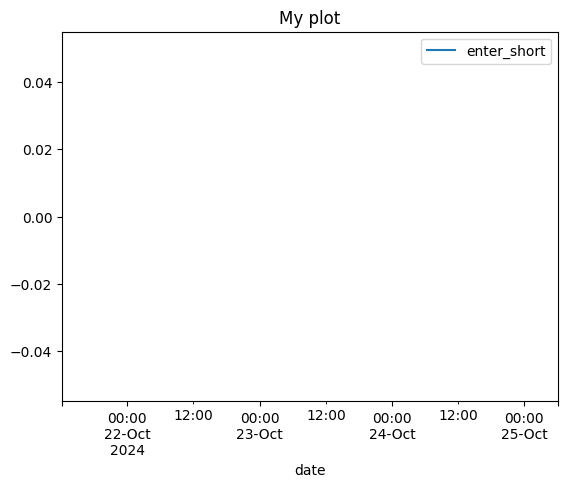

In [31]:
plot = dataframe.plot(kind='line', x='date', y='enter_short', title="My plot")

In [12]:
import ccxt
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema

In [2]:
bybit = ccxt.bybit()
binance = ccxt.binance()
kucoin = ccxt.kucoin()

In [14]:
symbol = 'BTC/USDT'
bybit_ob = bybit.fetchOrderBook(symbol)
binance_ob = bybit.fetchOrderBook(symbol)
kucoin_ob = bybit.fetchOrderBook(symbol)
bid_values = {
    'price': np.hstack((np.array(bybit_ob['bids'])[:,0], np.array(binance_ob['bids'])[:,0], np.array(kucoin_ob['bids'])[:,0])),
    'volume': np.hstack((np.array(bybit_ob['bids'])[:,1], np.array(binance_ob['bids'])[:,1], np.array(kucoin_ob['bids'])[:,1])),
    'side':'bid'
}
ask_values = {
    'price': np.hstack((np.array(bybit_ob['asks'])[:,0], np.array(binance_ob['asks'])[:,0], np.array(kucoin_ob['asks'])[:,0])),
    'volume': np.hstack((np.array(bybit_ob['asks'])[:,1], np.array(binance_ob['asks'])[:,1], np.array(kucoin_ob['asks'])[:,1])),
    'side':'ask'
}
bid_dataframe = pd.DataFrame(bid_values)
ask_dataframe = pd.DataFrame(ask_values)
dataframe = pd.concat((bid_dataframe,ask_dataframe))
dataframe = dataframe.groupby(['price','side']).sum().reset_index()
# dataframe.groupby('side').sum()

In [17]:
values = bybit.fetch_ohlcv(symbol=symbol,timeframe='5m')

In [19]:
df = pd.DataFrame(values, columns=('date','open','high','low','close','volume'))
df.tail()

,date,open,high,low,close,volume
195,1730985300000,74936.57,74979.66,74875.30,74885.84,79.389460
196,1730985600000,74885.84,74898.47,74795.20,74824.37,99.439370
197,1730985900000,74824.37,74919.26,74795.50,74809.00,94.096506
198,1730986200000,74809.00,74812.26,74733.01,74788.20,142.796230
199,1730986500000,74788.20,74788.86,74717.61,74733.66,60.830535


In [ ]:
pd.to_datetime(df.date,)

0     1970-01-01 00:00:00.000001730
1     1970-01-01 00:00:00.000001730
2     1970-01-01 00:00:00.000001730
3     1970-01-01 00:00:00.000001730
4     1970-01-01 00:00:00.000001730
                   ...             
195   1970-01-01 00:00:00.000001730
196   1970-01-01 00:00:00.000001730
197   1970-01-01 00:00:00.000001730
198   1970-01-01 00:00:00.000001730
199   1970-01-01 00:00:00.000001730
Name: date, Length: 200, dtype: datetime64[ns]

In [ ]:
min_peaks = argrelextrema(
    dataframe["low"].values, np.less,
    order=12
)
max_peaks = argrelextrema(
    dataframe["high"].values, np.greater,
    order=12
)

<Axes: ylabel='Frequency'>

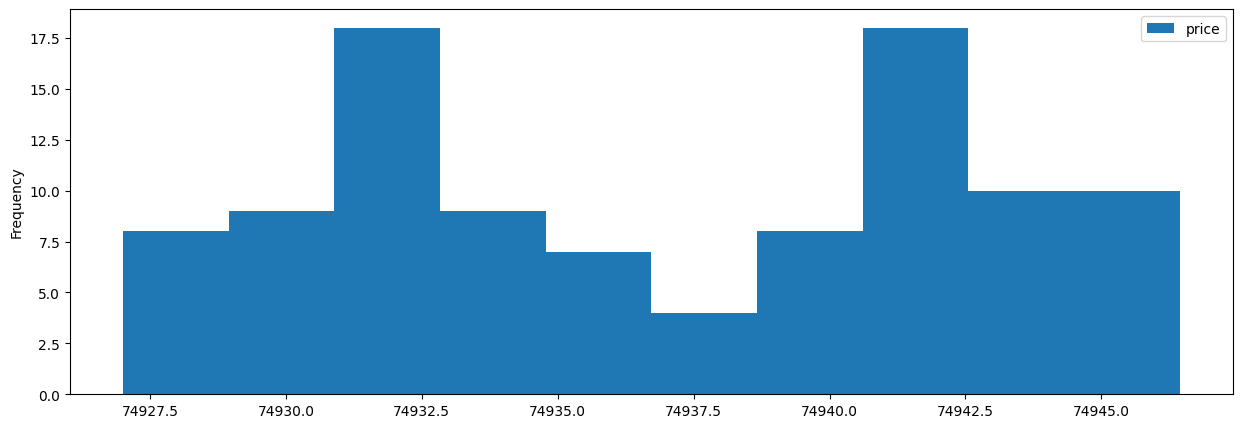

In [ ]:
import matplotlib.pyplot as plt

dfkeys = dataframe[:]

# Filter the dataframe based on the pivot column
high_values = dfkeys[dfkeys['pivot'] == 2]['high']
low_values = dfkeys[dfkeys['pivot'] == 1]['low']

# Define the bin width
bin_width = 0.003  # Change this value as needed

# Calculate the number of bins
bins = int((high_values.max() - low_values.min()) / bin_width)

# Create the histograms
plt.figure(figsize=(10, 5))
plt.hist(high_values, bins=bins, alpha=0.5, label='High Values', color='red')
plt.hist(low_values, bins=bins, alpha=0.5, label='Low Values', color='blue')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of High and Low Values')
plt.legend()